# Lidar/Vn File Boundary and Sync Diagnostics

This notebook sequentially tests and visualizes lidar/Vn file boundary and synchronization issues, as requested. Each section runs a diagnostic and generates a plot for one hypothesis.

key steps:

1. Identify how lidar file boundaries are detected and which files are read for chunk 285 and after index 182.
2. Validate that the correct lidar file for 4-30 is being read and contains the expected data.
3. Analyze how Vn data is interpolated and what time axis is used.
4. Investigate the meaning and use of hpl_start_time in the sync logic.
5. Compare time axes and recommend diagnostics or fixes.

In [1]:
# 1. Import Required Libraries
using Revise
using Dates
using Printf

using Pkg; Pkg.activate(".")

using Statistics
using PythonPlot
using JLD2
using NCDatasets
includet("lidar_vn_sync.jl")
using .LidarVNSync
includet("lidar_index.jl")
using .lidar_index

# Utility for pretty printing and diagnostics
diagnose(msg, x) = (println("\n--- $msg ---"); display(x))

  Activating project at `~/Projects/lidar/ASTRAL2024`
    CondaPkg Found dependencies: /Users/deszoeks/.julia/packages/CondaPkg/8GjrP/CondaPkg.toml
    CondaPkg Found dependencies: /Users/deszoeks/.julia/packages/PythonCall/83z4q/CondaPkg.toml
    CondaPkg Found dependencies: /Users/deszoeks/.julia/packages/PythonPlot/oS8x4/CondaPkg.toml
    CondaPkg Initialising pixi
             │ /Users/deszoeks/.julia/artifacts/d2fecc2a9fa3eac2108d3e4d9d155e6ff5dfd0b2/bin/pixi
             │ init
             │ --format pixi
             └ /Users/deszoeks/Projects/lidar/ASTRAL2024/.CondaPkg
✔ Created /Users/deszoeks/Projects/lidar/ASTRAL2024/.CondaPkg/pixi.toml
    CondaPkg Wrote /Users/deszoeks/Projects/lidar/ASTRAL2024/.CondaPkg/pixi.toml
             │ [dependencies]
             │ openssl = ">=3, <3.6"
             │ matplotlib = ">=1"
             │ 
             │     [dependencies.python]
             │     channel = "conda-forge"
             │     build = "*cp*"
             │     version 

diagnose (generic function with 1 method)

## 2. Define Test Functions

The following cells define or import the test functions for each diagnostic step.

In [2]:
# Test 1: Lidar file boundary detection and file selection for chunk 285 and after index 182
function test_lidar_file_boundaries(chunk=285, local_idx=182)
    lidar_idx = jldopen("lidar_index.jld2", "r") do f
        f["idx"]
    end
    lidar_dt = jldopen("lidar_dt.jld2", "r") do f
        f["dtime"]
    end
    # Global beam index for local_idx within this chunk
    global_idx = lidar_idx.ibeam_start[chunk] + local_idx - 1
    file_for_chunk = chunk_files(lidar_idx, chunk)
    t = lidar_dt[global_idx]
    return (file_for_chunk, global_idx, t)
end

test_lidar_file_boundaries (generic function with 3 methods)

## 3. Run Test 1: Lidar File Boundaries

Run the first test and display the file and time for chunk 285, index 182 and index 183.

Chunk containing 2024-04-29T23:57:30: chunk 285

Files for chunk 285:
  ifile= 48  Stare_116_20240429_23.nc
    2024-04-29T23:00:18.821 → 2024-04-29T23:59:59.533
  ifile= 49  Stare_116_20240430_00.nc
    2024-04-30T00:00:19.160 → 2024-04-30T00:59:59.570

Beam times around file boundaries:
  --- boundary after ifile 48 (local idx 182) ---
    local  180  2024-04-29T23:59:57.487 gap=1.02s
    local  181  2024-04-29T23:59:58.510 gap=1.02s
    local  182  2024-04-29T23:59:59.533 gap=1.02s
    local  183  2024-04-30T00:00:19.160 gap=19.63s
    local  184  2024-04-30T00:00:20.180 gap=1.02s
    local  185  2024-04-30T00:00:21.200 gap=1.02s

Max gap in chunk: 19.63 s at local idx 182
    2024-04-29T23:59:59.533 → 2024-04-30T00:00:19.160
FAIL: large gap of 19.6 s — April 30 data still missing from index


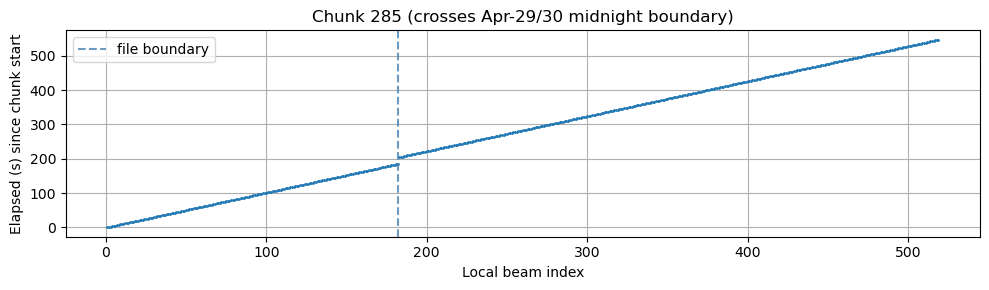

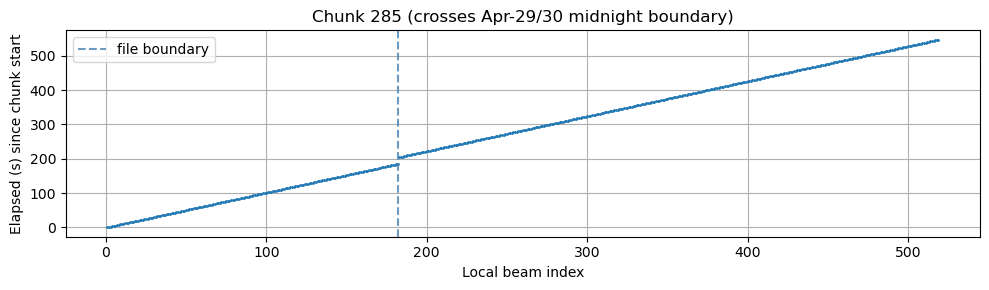

In [4]:
lidar_idx = jldopen("lidar_index.jld2", "r") do f; f["idx"]; end
lidar_dt  = jldopen("lidar_dt.jld2",    "r") do f; f["dtime"]; end

# Find the chunk containing the midnight Apr-29 → Apr-30 boundary
target_dt = DateTime("2024-04-29T23:57:30")
ic = dt_to_chunk(lidar_idx, target_dt)
@printf("Chunk containing %s: chunk %d\n", target_dt, ic)

ib_start = lidar_idx.ibeam_start[ic]
ib_end   = lidar_idx.ibeam_end[ic]
chunk_times = lidar_dt[ib_start:ib_end]
t0 = chunk_times[1]
secs = [Dates.value(t - t0) / 1000.0 for t in chunk_times]

# Files spanning this chunk
println("\nFiles for chunk $ic:")
for ifile in lidar_idx.ifile_first[ic]:lidar_idx.ifile_last[ic]
    t1 = lidar_dt[lidar_idx.file_ibeam_start[ifile]]
    t2 = lidar_dt[lidar_idx.file_ibeam_end[ifile]]
    @printf("  ifile=%3d  %s\n    %s → %s\n",
        ifile, basename(lidar_idx.filenames[ifile]), t1, t2)
end

# Print gaps around each file boundary
println("\nBeam times around file boundaries:")
for ifile in lidar_idx.ifile_first[ic]:lidar_idx.ifile_last[ic]-1
    k = lidar_idx.file_ibeam_end[ifile] - ib_start + 1
    println("  --- boundary after ifile $ifile (local idx $k) ---")
    for j in max(1,k-2):min(length(chunk_times),k+3)
        gap_str = j > 1 ? @sprintf(" gap=%.2fs", secs[j]-secs[j-1]) : ""
        @printf("    local %4d  %s%s\n", j, chunk_times[j], gap_str)
    end
end

# PASS/FAIL: max gap in chunk should be < 10 s
gaps = diff(secs)
max_gap, max_idx = findmax(gaps)
@printf("\nMax gap in chunk: %.2f s at local idx %d\n    %s → %s\n",
    max_gap, max_idx, chunk_times[max_idx], chunk_times[max_idx+1])
if max_gap < 10.0
    println("PASS: no spurious gap (max gap < 10 s)")
else
    println("FAIL: large gap of $(round(max_gap; digits=1)) s — April 30 data still missing from index")
end

# Plot seconds elapsed, mark file boundaries
PythonPlot.figure(figsize=(10,3))
PythonPlot.plot(collect(1:length(secs)), secs, marker=".", markersize=2, linestyle="none")
first_bdry = true
for ifile in lidar_idx.ifile_first[ic]:lidar_idx.ifile_last[ic]-1
    k = lidar_idx.file_ibeam_end[ifile] - ib_start + 1
    lbl = first_bdry ? "file boundary" : "_"
    PythonPlot.axvline(x=k, color="steelblue", linestyle="--", alpha=0.8, label=lbl)
    global first_bdry = false
end
PythonPlot.title("Chunk $ic (crosses Apr-29/30 midnight boundary)")
PythonPlot.xlabel("Local beam index")
PythonPlot.ylabel("Elapsed (s) since chunk start")
PythonPlot.legend()
PythonPlot.grid(true)
PythonPlot.tight_layout()
PythonPlot.gcf()

Inter-file boundary gaps (N=990):
  median: 19.03 s
  mean:   461.01 s
  min:    1.02 s
  max:    432018.70 s
  gaps > 10 s: 989  (99.9%)
  gaps > 36 s (chunk break): 83

Apr-29→30 boundary gap: 19.63 s  (file: Stare_116_20240430_00.nc)
(excluding 8 gaps > 60 s from histogram)


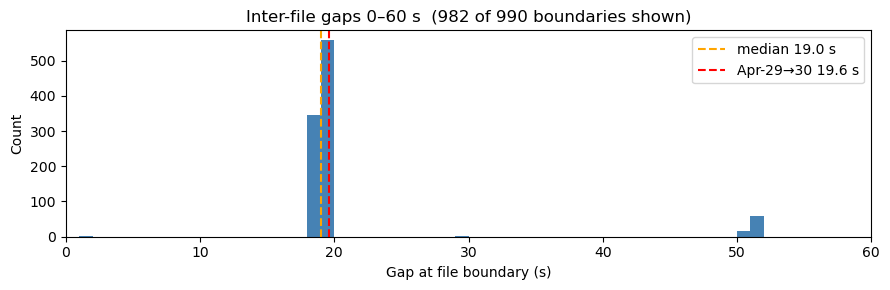

Python: None

In [8]:
# ── Are ~20 s inter-file gaps real or anomalous? ─────────────────────────────
# Compute the gap at every file boundary and compare to the Apr-29/30 gap.
lidar_idx = jldopen("lidar_index.jld2", "r") do f; f["idx"]; end
lidar_dt  = jldopen("lidar_dt.jld2",    "r") do f; f["dtime"]; end

nfiles = length(lidar_idx.filenames)
boundary_gaps = Float64[]   # gap in seconds at each file boundary
boundary_files = String[]   # name of the later file (start of gap)

for ifile in 1:nfiles-1
    t_last  = lidar_dt[lidar_idx.file_ibeam_end[ifile]]
    t_first = lidar_dt[lidar_idx.file_ibeam_start[ifile+1]]
    gap_s   = Dates.value(t_first - t_last) / 1000.0
    push!(boundary_gaps, gap_s)
    push!(boundary_files, basename(lidar_idx.filenames[ifile+1]))
end

# Summary statistics
@printf("Inter-file boundary gaps (N=%d):\n", length(boundary_gaps))
@printf("  median: %.2f s\n", median(boundary_gaps))
@printf("  mean:   %.2f s\n", mean(boundary_gaps))
@printf("  min:    %.2f s\n", minimum(boundary_gaps))
@printf("  max:    %.2f s\n", maximum(boundary_gaps))
@printf("  gaps > 10 s: %d  (%.1f%%)\n",
    count(g -> g > 10.0, boundary_gaps),
    100 * count(g -> g > 10.0, boundary_gaps) / length(boundary_gaps))
@printf("  gaps > 36 s (chunk break): %d\n", count(g -> g > 36.0, boundary_gaps))

# Show the Apr-29/30 specific boundary
target = "Stare_116_20240430_00.nc"
idx430 = findfirst(==(target), boundary_files)
if !isnothing(idx430)
    @printf("\nApr-29→30 boundary gap: %.2f s  (file: %s)\n",
        boundary_gaps[idx430], boundary_files[idx430])
end

# Histogram of gaps — show only 0–60 s range
xlim_s = 60.0
plot_gaps = filter(g -> g <= xlim_s, boundary_gaps)
n_excluded = length(boundary_gaps) - length(plot_gaps)
n_excluded > 0 && @printf("(excluding %d gaps > %.0f s from histogram)\n", n_excluded, xlim_s)

PythonPlot.figure(figsize=(9,3))
PythonPlot.hist(plot_gaps, bins=range(0, xlim_s, length=61), color="steelblue", edgecolor="none")
PythonPlot.axvline(x=median(plot_gaps), color="orange", linestyle="--", label="median $(round(median(plot_gaps); digits=1)) s")
if !isnothing(idx430) && boundary_gaps[idx430] <= xlim_s
    PythonPlot.axvline(x=boundary_gaps[idx430], color="red", linestyle="--",
        label="Apr-29→30 $(round(boundary_gaps[idx430]; digits=1)) s")
end
PythonPlot.xlim(0, xlim_s)
PythonPlot.xlabel("Gap at file boundary (s)")
PythonPlot.ylabel("Count")
PythonPlot.title("Inter-file gaps 0–$(Int(xlim_s)) s  ($(length(plot_gaps)) of $(nfiles-1) boundaries shown)")
PythonPlot.legend()
PythonPlot.tight_layout()
# PythonPlot.gcf()